# Plot: VBench Total Lite Score by S and R (3D bar chart)

This notebook stores `score<S,R>` as matrix CSV files, converts them into plotting-friendly tabular form, and renders a high-quality 3D bar chart.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib import cm
from matplotlib.colors import Normalize


In [2]:
# Plot configuration
FIGSIZE = (10.5, 7.2)
PNG_DPI = 600
PDF_DPI = 600
BAR_DX = 0.68
BAR_DY = 0.68
BAR_EDGEWIDTH = 0.55
Z_TICK_COUNT = 6
VIEW_ELEV = 24
VIEW_AZIM = -58
Z_PAD_MIN = 0.9
Z_PAD_SCALE = 0.55
COLOR_PAD_MIN = 0.6
COLOR_PAD_SCALE = 0.35
COLORMAP = "RdBu_r"
X_AXIS_LABEL = "Sink"
Y_AXIS_LABEL = "Recent"
Z_AXIS_LABEL = "VBench Total Lite Score"
PLOT_TITLE = "VBench Total Lite Score by S and R"
SAVEFIG_BBOX = "tight"

PLOT_RC = {
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Liberation Serif", "Times", "DejaVu Serif"],
    "font.size": 12,
    "axes.titlesize": 16,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "figure.titlesize": 16,
    "axes.linewidth": 0.9,
    "savefig.bbox": SAVEFIG_BBOX,
    "savefig.facecolor": "white",
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
}

plt.rcParams.update(PLOT_RC)


In [3]:
# Data configuration
TASK_DIRNAME = "26Mar13-PyramidForcingSweep"
PNG_FILENAME = "vbench_total_lite_sr_3d.png"
PDF_FILENAME = "vbench_total_lite_sr_3d.pdf"


def resolve_repo_root() -> Path:
    """Support running the notebook from repo root or from the notebook directory."""
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        data_file = candidate / "data" / TASK_DIRNAME / "total_lite_mean_matrix.csv"
        if data_file.exists():
            return candidate
    raise FileNotFoundError(f"Could not locate data/{TASK_DIRNAME}/total_lite_mean_matrix.csv")


REPO_ROOT = resolve_repo_root()
DATA_DIR = REPO_ROOT / "data" / TASK_DIRNAME
FIG_DIR = REPO_ROOT / "figures" / TASK_DIRNAME
FIG_DIR.mkdir(parents=True, exist_ok=True)
PNG_OUTPUT_PATH = FIG_DIR / PNG_FILENAME
PDF_OUTPUT_PATH = FIG_DIR / PDF_FILENAME
{
    "data_dir": str(DATA_DIR),
    "png_output": str(PNG_OUTPUT_PATH),
    "pdf_output": str(PDF_OUTPUT_PATH),
}


{'data_dir': '/home/winbeau/Tools/jupyter-plot/data/26Mar13-PyramidForcingSweep',
 'png_output': '/home/winbeau/Tools/jupyter-plot/figures/26Mar13-PyramidForcingSweep/vbench_total_lite_sr_3d.png',
 'pdf_output': '/home/winbeau/Tools/jupyter-plot/figures/26Mar13-PyramidForcingSweep/vbench_total_lite_sr_3d.pdf'}

In [4]:
def load_score_matrix(data_dir: str | Path, kind: str = "mean") -> pd.DataFrame:
    """Load the matrix CSV for mean or std values."""
    if kind not in {"mean", "std"}:
        raise ValueError("kind must be 'mean' or 'std'")

    filename = f"total_lite_{kind}_matrix.csv"
    matrix = pd.read_csv(Path(data_dir) / filename).set_index("r")
    matrix.index = matrix.index.astype(int)
    return matrix


def matrix_to_long(data_dir: str | Path, kind: str = "mean") -> pd.DataFrame:
    """Convert a matrix CSV into tidy rows keyed by S and R."""
    matrix = load_score_matrix(data_dir, kind=kind)
    long_df = (
        matrix.rename_axis(index="r", columns="s")
        .stack()
        .rename(f"score_{kind}")
        .reset_index()
        .sort_values(["s", "r"], kind="stable")
        .reset_index(drop=True)
    )
    long_df["s"] = long_df["s"].str.removeprefix("S").astype(int)
    return long_df


def build_bar3d_input(data_dir: str | Path) -> pd.DataFrame:
    """Build a unified table for plotting or downstream conversion."""
    mean_df = matrix_to_long(data_dir, kind="mean")
    std_df = matrix_to_long(data_dir, kind="std")

    bars = mean_df.merge(std_df, on=["s", "r"], how="inner", validate="one_to_one")
    s_order = sorted(bars["s"].unique())
    r_order = sorted(bars["r"].unique())

    s_to_x = {s: idx for idx, s in enumerate(s_order)}
    r_to_y = {r: idx for idx, r in enumerate(r_order)}

    bars["x"] = bars["s"].map(s_to_x).astype(float)
    bars["y"] = bars["r"].map(r_to_y).astype(float)
    bars["dx"] = BAR_DX
    bars["dy"] = BAR_DY
    return bars


In [5]:
bars = build_bar3d_input(DATA_DIR)
bars.head()


,r,s,score_mean,score_std,x,y,dx,dy
0,2,1,80.098,3.266,0.0,0.0,0.68,0.68
1,3,1,81.182,3.365,0.0,1.0,0.68,0.68
2,4,1,81.685,3.485,0.0,2.0,0.68,0.68
3,5,1,81.642,3.649,0.0,3.0,0.68,0.68
4,6,1,81.588,3.478,0.0,4.0,0.68,0.68


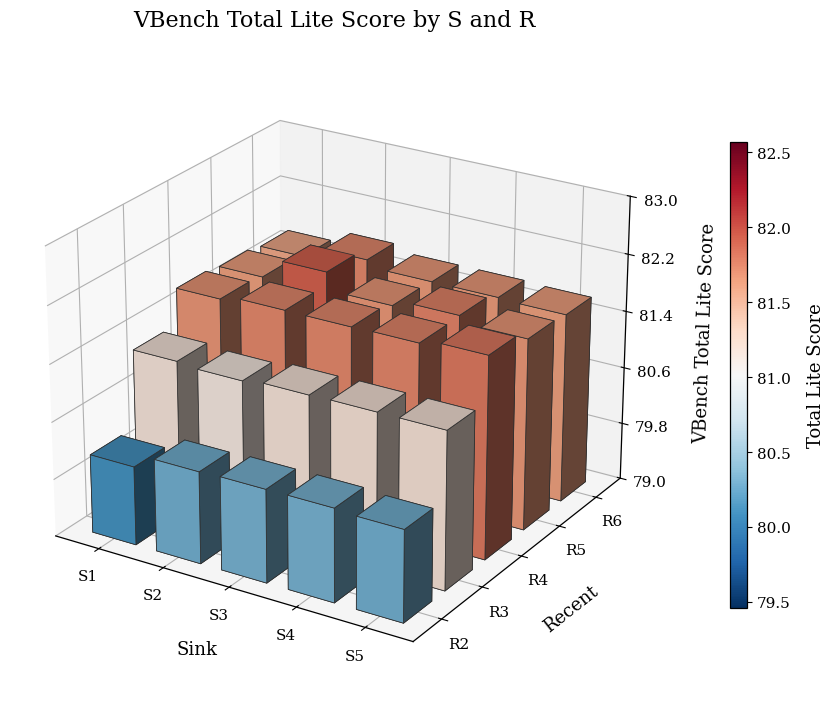

(PosixPath('/home/winbeau/Tools/jupyter-plot/figures/26Mar13-PyramidForcingSweep/vbench_total_lite_sr_3d.png'),
 PosixPath('/home/winbeau/Tools/jupyter-plot/figures/26Mar13-PyramidForcingSweep/vbench_total_lite_sr_3d.pdf'))

In [6]:
def plot_total_lite_score_sr_3d(
    data_dir: str | Path,
    png_output_path: str | Path,
    pdf_output_path: str | Path,
) -> tuple[Path, Path]:
    """Render a high-quality 3D bar chart for VBench Total Lite scores."""
    bars = build_bar3d_input(data_dir)
    s_values = sorted(bars["s"].unique())
    r_values = sorted(bars["r"].unique())

    fig = plt.figure(figsize=FIGSIZE)
    ax = fig.add_subplot(111, projection="3d")

    score_min = float(bars["score_mean"].min())
    score_max = float(bars["score_mean"].max())
    score_span = score_max - score_min
    z_pad = max(Z_PAD_MIN, score_span * Z_PAD_SCALE)
    color_pad = max(COLOR_PAD_MIN, score_span * COLOR_PAD_SCALE)

    z_base = np.floor((score_min - z_pad) * 10.0) / 10.0
    z_top = np.ceil((score_max + z_pad) * 10.0) / 10.0

    bar_base = np.full(len(bars), z_base, dtype=float)
    bar_height = bars["score_mean"].to_numpy() - z_base

    cmap = plt.get_cmap(COLORMAP)
    norm = Normalize(vmin=score_min - color_pad, vmax=score_max + color_pad)
    colors = cmap(norm(bars["score_mean"].to_numpy()))

    ax.bar3d(
        bars["x"].to_numpy(),
        bars["y"].to_numpy(),
        bar_base,
        bars["dx"].to_numpy(),
        bars["dy"].to_numpy(),
        bar_height,
        color=colors,
        edgecolor="#2F2F2F",
        linewidth=BAR_EDGEWIDTH,
        shade=True,
    )

    ax.set_xticks(np.arange(len(s_values)) + BAR_DX / 2)
    ax.set_xticklabels([f"S{s}" for s in s_values])
    ax.set_yticks(np.arange(len(r_values)) + BAR_DY / 2)
    ax.set_yticklabels([f"R{r}" for r in r_values])
    ax.set_xlabel(X_AXIS_LABEL, labelpad=12)
    ax.set_ylabel(Y_AXIS_LABEL, labelpad=12)
    ax.set_zlabel(Z_AXIS_LABEL, labelpad=14)
    ax.set_title(PLOT_TITLE, pad=18)
    ax.set_zlim(z_base, z_top)
    ax.set_zticks(np.round(np.linspace(z_base, z_top, Z_TICK_COUNT), 2))
    ax.view_init(elev=VIEW_ELEV, azim=VIEW_AZIM)
    ax.tick_params(axis="x", pad=3)
    ax.tick_params(axis="y", pad=3)
    ax.tick_params(axis="z", pad=5)

    mappable = cm.ScalarMappable(norm=norm, cmap=cmap)
    mappable.set_array([])
    cbar = fig.colorbar(mappable, ax=ax, shrink=0.72, pad=0.08, aspect=28)
    cbar.set_label("Total Lite Score", rotation=90, labelpad=12)

    png_output = Path(png_output_path)
    pdf_output = Path(pdf_output_path)
    fig.subplots_adjust(left=0.02, right=0.88, bottom=0.03, top=0.93)
    plt.savefig(png_output, dpi=PNG_DPI, bbox_inches=SAVEFIG_BBOX)
    plt.savefig(pdf_output, dpi=PDF_DPI, bbox_inches=SAVEFIG_BBOX)
    if "get_ipython" in globals() and get_ipython() is not None:
        display(fig)
    plt.close(fig)
    return png_output, pdf_output


plot_total_lite_score_sr_3d(DATA_DIR, PNG_OUTPUT_PATH, PDF_OUTPUT_PATH)
